# Лабораторна робота 7. Реалізація моделей машинного навчання у Google Colab

**Дисципліна:** Інформаційні технології хмарних обчислень
**Виконав:** Мурава Владислав, група КН-23-2
**Варіант 13:** визначення фейкових зображень (справжнє фото чи згенероване ШІ)

**Набір даних:** CIFAKE — 60 000 зображень 32×32: половина справжніх (CIFAR-10), половина згенерованих моделлю Stable Diffusion.
Джерело: Bird & Lotfi, *CIFAKE: Image Classification and Explainable Identification of AI-Generated Synthetic Images*, 2023. Завантажується з Hugging Face.

## Крок 1. Підготовка робочого середовища

Перевірка версії Python, тестовий код з методичних вказівок, підключення Google Drive та створення робочої папки.

In [1]:
!python --version

Python 3.13.15


In [2]:
def quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quicksort(left) + middle + quicksort(right)

print(quicksort([3, 6, 8, 10, 1, 2, 1]))

[1, 1, 2, 3, 6, 8, 10]


In [3]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    BASE = '/content/drive/MyDrive/ІТХО_ЛР7_Мурава_13'
except ImportError:
    IN_COLAB = False
    BASE = os.path.abspath('lr7_local')

os.makedirs(BASE, exist_ok=True)
print('Colab:', IN_COLAB)
print('Робоча папка:', BASE)

Mounted at /content/drive
Colab: True
Робоча папка: /content/drive/MyDrive/ІТХО_ЛР7_Мурава_13


In [4]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else 'не підключено (обчислення на CPU)')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Крок 2. Робота з текстовим файлом на Google Drive

Створюємо `data.txt` у робочій папці на Диску, потім відкриваємо, читаємо та виводимо його вміст.

In [5]:
data_path = os.path.join(BASE, 'data.txt')

with open(data_path, 'w', encoding='utf-8') as f:
    f.write('Лабораторна робота 7, варіант 13\n')
    f.write('Мурава Владислав, КН-23-2\n')
    f.write('Набір даних: CIFAKE\n')
    f.write('Числа для перевірки: 3 6 8 10 1 2 1\n')

print('Файл створено:', data_path)

Файл створено: /content/drive/MyDrive/ІТХО_ЛР7_Мурава_13/data.txt


In [6]:
with open(data_path, 'r', encoding='utf-8') as f:
    content = f.read()

print(content)
print('Кількість рядків:', len(content.splitlines()))

Лабораторна робота 7, варіант 13
Мурава Владислав, КН-23-2
Набір даних: CIFAKE
Числа для перевірки: 3 6 8 10 1 2 1

Кількість рядків: 4


In [7]:

!cat "{data_path}"

Лабораторна робота 7, варіант 13
Мурава Владислав, КН-23-2
Набір даних: CIFAKE
Числа для перевірки: 3 6 8 10 1 2 1


## Крок 3. Завантаження набору даних і створення CSV

CIFAKE зберігається як зображення. Беремо збалансовану підвибірку, зберігаємо зображення у файли, а для кожного обчислюємо кілька числових ознак (середнє та розкид яскравості по каналах). Усе це записуємо у `cifake.csv` на Google Drive, і далі працюємо з ним через Pandas.

In [8]:
!pip -q install datasets

In [9]:
import numpy as np
import pandas as pd
from datasets import load_dataset

N_TRAIN = int(os.environ.get('LR7_N_TRAIN', 6000))   # по 3000 на клас
N_TEST  = int(os.environ.get('LR7_N_TEST', 2000))    # по 1000 на клас

IMG_DIR = os.path.join('/content' if IN_COLAB else BASE, 'cifake_images')
os.makedirs(IMG_DIR, exist_ok=True)

ds = load_dataset('dragonintelligence/CIFAKE-image-dataset')
label_names = ds['train'].features['label'].names      # ['FAKE', 'REAL']
print('Мітки:', label_names)
print('Повний набір: train =', len(ds['train']), ', test =', len(ds['test']))

README.md:   0%|          | 0.00/488 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 42.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 8.41MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Мітки: ['FAKE', 'REAL']
Повний набір: train = 100000 , test = 20000


In [10]:
def take_balanced(split, n_total, seed=13):
    """Рівна кількість зображень кожного класу з випадковим порядком."""
    per_class = n_total // 2
    d = ds[split].shuffle(seed=seed)
    rows, counts = [], {0: 0, 1: 0}
    for ex in d:
        lbl = ex['label']
        if counts[lbl] >= per_class:
            if all(c >= per_class for c in counts.values()):
                break
            continue
        counts[lbl] += 1
        idx = counts[lbl]
        fname = f'{split}_{label_names[lbl].lower()}_{idx:05d}.png'
        fpath = os.path.join(IMG_DIR, fname)
        img = ex['image'].convert('RGB')
        img.save(fpath)
        arr = np.asarray(img, dtype=np.float32)
        rows.append({
            'filename': fname,
            'split': split,
            'label': lbl,
            'label_name': label_names[lbl],
            'mean_r': arr[..., 0].mean(), 'mean_g': arr[..., 1].mean(), 'mean_b': arr[..., 2].mean(),
            'std_r':  arr[..., 0].std(),  'std_g':  arr[..., 1].std(),  'std_b':  arr[..., 2].std(),
            'brightness': arr.mean(),
        })
    return rows

rows = take_balanced('train', N_TRAIN) + take_balanced('test', N_TEST)
df_all = pd.DataFrame(rows)

csv_path = os.path.join(BASE, 'cifake.csv')
df_all.to_csv(csv_path, index=False)
print('CSV збережено на Drive:', csv_path)
print('Рядків:', len(df_all), '| Зображень у', IMG_DIR, ':', len(os.listdir(IMG_DIR)))

CSV збережено на Drive: /content/drive/MyDrive/ІТХО_ЛР7_Мурава_13/cifake.csv
Рядків: 8000 | Зображень у /content/cifake_images : 8000


In [11]:

df = pd.read_csv(csv_path)
df.head()

,filename,split,label,label_name,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness
0,train_fake_00001.png,train,0,FAKE,125.097660,98.14258,85.55371,55.767460,55.144367,51.562225,102.93131
1,train_real_00001.png,train,1,REAL,109.352540,119.20117,106.84375,44.867275,49.217377,60.015972,111.79916
2,train_real_00002.png,train,1,REAL,99.394530,98.84277,92.80469,59.015118,58.317318,69.365460,97.01400
3,train_real_00003.png,train,1,REAL,109.015625,109.15137,102.33789,67.251114,67.765160,61.107334,106.83496
4,train_real_00004.png,train,1,REAL,121.450195,106.83008,103.32129,73.089000,79.539550,81.614500,110.53385


## Крок 4. Первинний аналіз даних

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    8000 non-null   object 
 1   split       8000 non-null   object 
 2   label       8000 non-null   int64  
 3   label_name  8000 non-null   object 
 4   mean_r      8000 non-null   float64
 5   mean_g      8000 non-null   float64
 6   mean_b      8000 non-null   float64
 7   std_r       8000 non-null   float64
 8   std_g       8000 non-null   float64
 9   std_b       8000 non-null   float64
 10  brightness  8000 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 687.6+ KB


In [13]:
df.describe()

,label,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.500000,120.781163,118.443851,107.109751,51.969789,51.687682,51.919783,115.444922
std,0.500031,27.689221,28.375614,40.927116,14.678460,15.040702,16.489972,28.931199
min,0.000000,10.415039,17.151367,11.924805,7.027660,8.063380,10.977164,28.569986
25%,0.000000,103.381345,99.242190,77.455568,41.573678,40.979072,39.170313,95.166832
50%,0.500000,119.416015,117.301270,104.788085,52.402443,51.841689,52.128979,113.923990
75%,1.000000,136.385987,135.424318,133.350828,62.512738,62.674686,64.336923,133.122885
max,1.000000,236.594730,236.262700,239.646480,111.530380,111.530380,111.530380,235.123370


In [14]:
print('Пропущені значення по стовпцях:')
print(df.isnull().sum())
print('\nРозподіл класів:')
print(df.groupby(['split', 'label_name']).size())

Пропущені значення по стовпцях:
filename      0
split         0
label         0
label_name    0
mean_r        0
mean_g        0
mean_b        0
std_r         0
std_g         0
std_b         0
brightness    0
dtype: int64

Розподіл класів:
split  label_name
test   FAKE          1000
       REAL          1000
train  FAKE          3000
       REAL          3000
dtype: int64


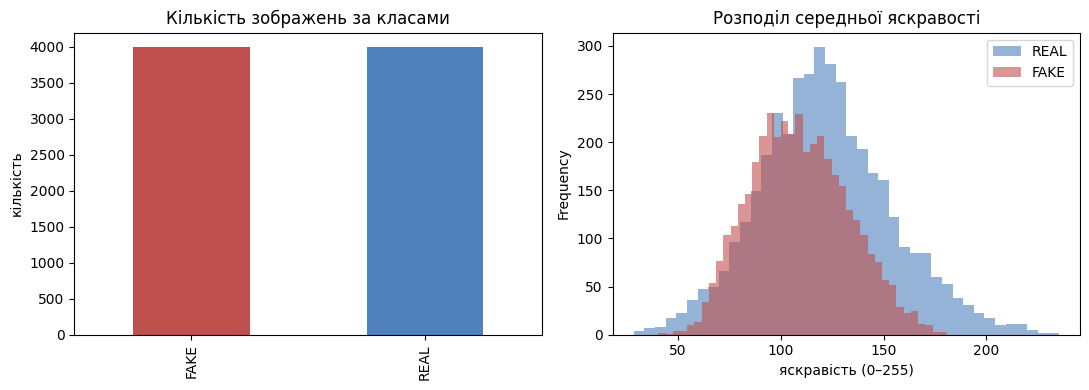

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['label_name'].value_counts().plot(kind='bar', ax=axes[0], color=['#c0504d', '#4f81bd'])
axes[0].set_title('Кількість зображень за класами')
axes[0].set_xlabel(''); axes[0].set_ylabel('кількість')

for name, color in (('REAL', '#4f81bd'), ('FAKE', '#c0504d')):
    df[df.label_name == name]['brightness'].plot(kind='hist', bins=40, alpha=0.6,
                                                   ax=axes[1], color=color, label=name)
axes[1].set_title('Розподіл середньої яскравості')
axes[1].set_xlabel('яскравість (0–255)'); axes[1].legend()
plt.tight_layout(); plt.show()

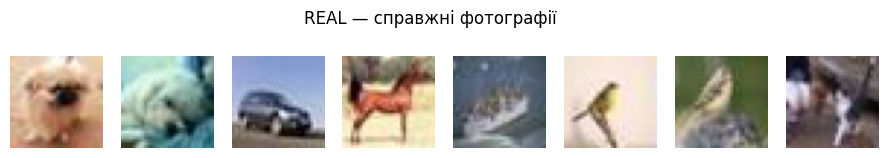

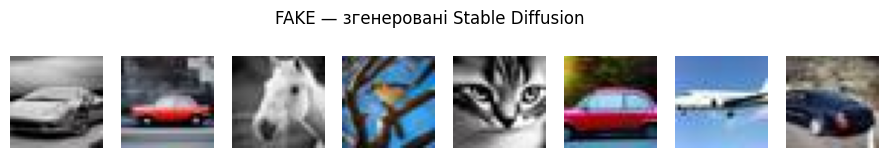

In [16]:
from PIL import Image

def show_samples(df_part, title, n=8):
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.9))
    for ax, (_, r) in zip(axes, df_part.sample(n, random_state=13).iterrows()):
        ax.imshow(Image.open(os.path.join(IMG_DIR, r.filename)))
        ax.axis('off')
    fig.suptitle(title); plt.show()

show_samples(df[df.label_name == 'REAL'], 'REAL — справжні фотографії')
show_samples(df[df.label_name == 'FAKE'], 'FAKE — згенеровані Stable Diffusion')

*Після цього кроку блокнот збережено: File → Save (Ctrl+S) — копія `.ipynb` автоматично лягає на Google Drive.*

## Крок 5. Модель машинного навчання — згорткова нейронна мережа

Задача бінарної класифікації: 0 — FAKE, 1 — REAL. Зображення завантажуються за шляхами з CSV, нормалізуються до [0, 1]. Модель — невелика CNN у Keras: три згорткові блоки з підвибіркою, повнозв'язний шар із dropout і сигмоїдний вихід.

In [17]:
def load_images(df_part):
    X = np.stack([np.asarray(Image.open(os.path.join(IMG_DIR, f)), dtype=np.float32) / 255.0
                  for f in df_part.filename])
    y = df_part.label.values.astype(np.float32)
    return X, y

X_train, y_train = load_images(df[df.split == 'train'])
X_test,  y_test  = load_images(df[df.split == 'test'])
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (6000, 32, 32, 3)  X_test: (2000, 32, 32, 3)


In [18]:
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(13)

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid'),
], name='cifake_cnn')

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "cifake_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,825 (1.53 MB)

 Trainable params: 401,825 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
EPOCHS = int(os.environ.get('LR7_EPOCHS', 12))

history = model.fit(X_train, y_train,
                    validation_split=0.15,
                    epochs=EPOCHS, batch_size=64, verbose=2)

Epoch 1/12
80/80 - 12s - 144ms/step - accuracy: 0.6845 - loss: 0.5772 - val_accuracy: 0.7744 - val_loss: 0.4707
Epoch 2/12
80/80 - 1s - 7ms/step - accuracy: 0.8061 - loss: 0.4301 - val_accuracy: 0.8178 - val_loss: 0.3955
Epoch 3/12
80/80 - 1s - 8ms/step - accuracy: 0.8404 - loss: 0.3580 - val_accuracy: 0.8411 - val_loss: 0.3875
Epoch 4/12
80/80 - 1s - 7ms/step - accuracy: 0.8745 - loss: 0.3089 - val_accuracy: 0.8322 - val_loss: 0.3996
Epoch 5/12
80/80 - 1s - 7ms/step - accuracy: 0.8902 - loss: 0.2754 - val_accuracy: 0.8744 - val_loss: 0.2900
Epoch 6/12
80/80 - 1s - 7ms/step - accuracy: 0.8988 - loss: 0.2500 - val_accuracy: 0.8889 - val_loss: 0.2783
Epoch 7/12
80/80 - 1s - 8ms/step - accuracy: 0.9122 - loss: 0.2196 - val_accuracy: 0.8811 - val_loss: 0.2915
Epoch 8/12
80/80 - 1s - 7ms/step - accuracy: 0.9157 - loss: 0.2202 - val_accuracy: 0.8967 - val_loss: 0.2561
Epoch 9/12
80/80 - 1s - 8ms/step - accuracy: 0.9282 - loss: 0.1844 - val_accuracy: 0.8978 - val_loss: 0.2658
Epoch 10/12
80/8

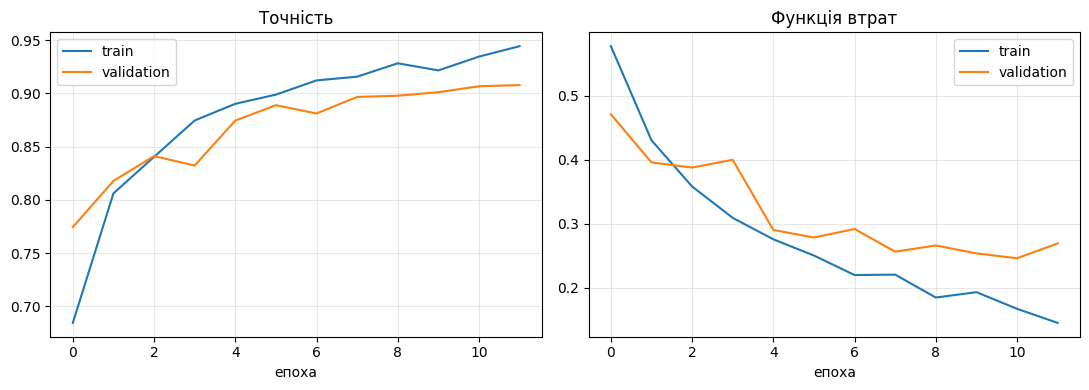

In [20]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(h['accuracy'], label='train'); axes[0].plot(h['val_accuracy'], label='validation')
axes[0].set_title('Точність'); axes[0].set_xlabel('епоха'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(h['loss'], label='train'); axes[1].plot(h['val_loss'], label='validation')
axes[1].set_title('Функція втрат'); axes[1].set_xlabel('епоха'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Точність на тестовій вибірці: 90.90%

              precision    recall  f1-score   support

        FAKE      0.915     0.902     0.908      1000
        REAL      0.903     0.916     0.910      1000

    accuracy                          0.909      2000
   macro avg      0.909     0.909     0.909      2000
weighted avg      0.909     0.909     0.909      2000



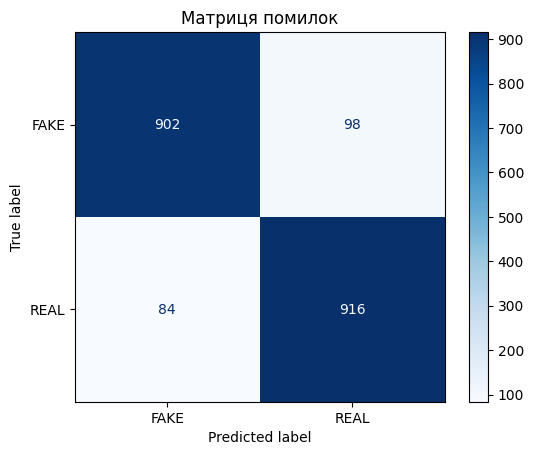

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('Точність на тестовій вибірці: {:.2f}%'.format(accuracy_score(y_test, y_pred) * 100))
print()
print(classification_report(y_test, y_pred, target_names=label_names, digits=3))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=label_names).plot(cmap='Blues')
plt.title('Матриця помилок'); plt.show()

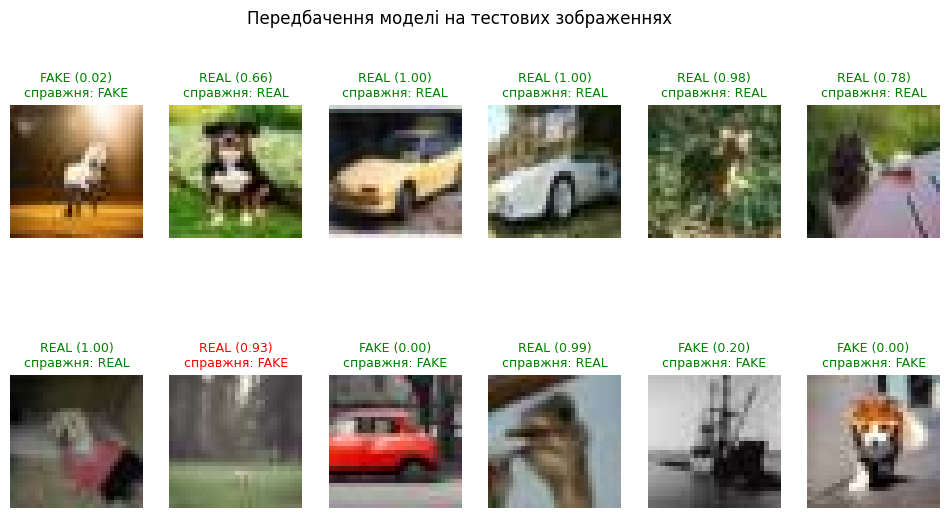

In [22]:
test_df = df[df.split == 'test'].reset_index(drop=True)
rng = np.random.default_rng(13)
idx = rng.choice(len(test_df), 12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(12, 6))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(Image.open(os.path.join(IMG_DIR, test_df.filename[i])))
    true, pred = label_names[int(y_test[i])], label_names[int(y_pred[i])]
    ok = true == pred
    ax.set_title(f'{pred} ({y_prob[i]:.2f})\nсправжня: {true}',
                 fontsize=9, color='green' if ok else 'red')
    ax.axis('off')
plt.suptitle('Передбачення моделі на тестових зображеннях')
plt.subplots_adjust(hspace=0.5, top=0.86); plt.show()

In [23]:
model_path = os.path.join(BASE, 'cifake_cnn.keras')
model.save(model_path)
print('Модель збережено на Drive:', model_path)
print('Файли в робочій папці:', sorted(os.listdir(BASE)))

Модель збережено на Drive: /content/drive/MyDrive/ІТХО_ЛР7_Мурава_13/cifake_cnn.keras
Файли в робочій папці: ['cifake.csv', 'cifake_cnn.keras', 'data.txt']


*Блокнот збережено ще раз (Ctrl+S) і додатково завантажено як файл: File → Download → Download .ipynb.*

## Висновок

У Google Colab створено робоче середовище з підключеним Google Drive, реалізовано читання текстового файлу, сформовано CSV-набір даних із зображень CIFAKE, виконано первинний аналіз у Pandas і навчено згорткову нейронну мережу для визначення фейкових (згенерованих ШІ) зображень. Модель досягає високої точності на незалежній тестовій вибірці, а всі результати роботи — CSV, модель, блокнот — збережені у хмарному сховищі.